In [2]:
# Import required modules
import datetime
from datetime import timedelta
import contextily as ctx
from adjustText import adjust_text
from dask import compute
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from pprint import pprint
from shapely.geometry import Point
import warnings
import xarray as xr

%matplotlib notebook

# Add that all figures should be inlined
%matplotlib inline

In [3]:
def filter_stations_by_obs_per_year(
    ds,
    var='snw',
    n=1,
    start_date='2010-01-01',
    end_date='2021-12-31',
    measurement_types=None
):
    """
    Filters stations based on a minimum number of valid observations per year for a given variable.
    Optionally filters by measurement type if provided.

    Parameters:
        ds (xarray.Dataset): Dataset with dimensions (time, station_id)
        var (str): Variable to check (e.g., 'snw')
        n (int): Minimum number of valid observations per year
        start_date (str): Start date for filtering
        end_date (str): End date for filtering
        measurement_types (list or None): Values of 'type_mes' to filter on. None or [None] for no filtering.

    Returns:
        xarray.Dataset: Dataset filtered to include only qualifying station_ids
    """
    # 1. Restrict to desired time range
    ds_filtered = ds.sel(time=slice(start_date, end_date))

    # 2. Optionally filter by measurement type if provided, checking logic carefully
    if measurement_types is not None and measurement_types != [None]:
        # A real filtering list -- must check that type_mes exists
        if "type_mes" not in ds_filtered:
            raise ValueError("measurement_types filtering requested but 'type_mes' is not in dataset.")
        # If measurement_types is empty, no stations should qualify
        if len(measurement_types) == 0:
            type_mask = xr.full_like(ds_filtered[var], False, dtype=bool)
        else:
            # Use .isin to match any selected type
            type_mask = ds_filtered["type_mes"].isin(measurement_types)
    else:
        # No filter requested (measurement_types is None or [None])
        type_mask = xr.full_like(ds_filtered[var], True, dtype=bool)

    # 3. Identify valid observations (non-NaN) and (optionally) measurement type
    valid = (~ds_filtered[var].isnull()) & type_mask

    # 4. Extract years using .dt accessor
    years = ds_filtered.time.dt.year

    # 5. Group by year and sum valid obs per station per year
    obs_per_year = valid.groupby(xr.DataArray(years, coords={"time": ds_filtered.time}, dims="time").rename("year")).sum(dim="time")

    # 6. Check that all years for a station meet the n threshold
    station_mask = (obs_per_year >= n).all(dim="year")

    # 7. Additionally, drop stations with zero observations over the full period (not just per year)
    total_valid_obs = valid.sum(dim="time")
    station_mask = station_mask & (total_valid_obs > 0)

    # 8. Apply mask to original filtered dataset
    return ds_filtered.sel(station_id=ds_filtered.station_id[station_mask])

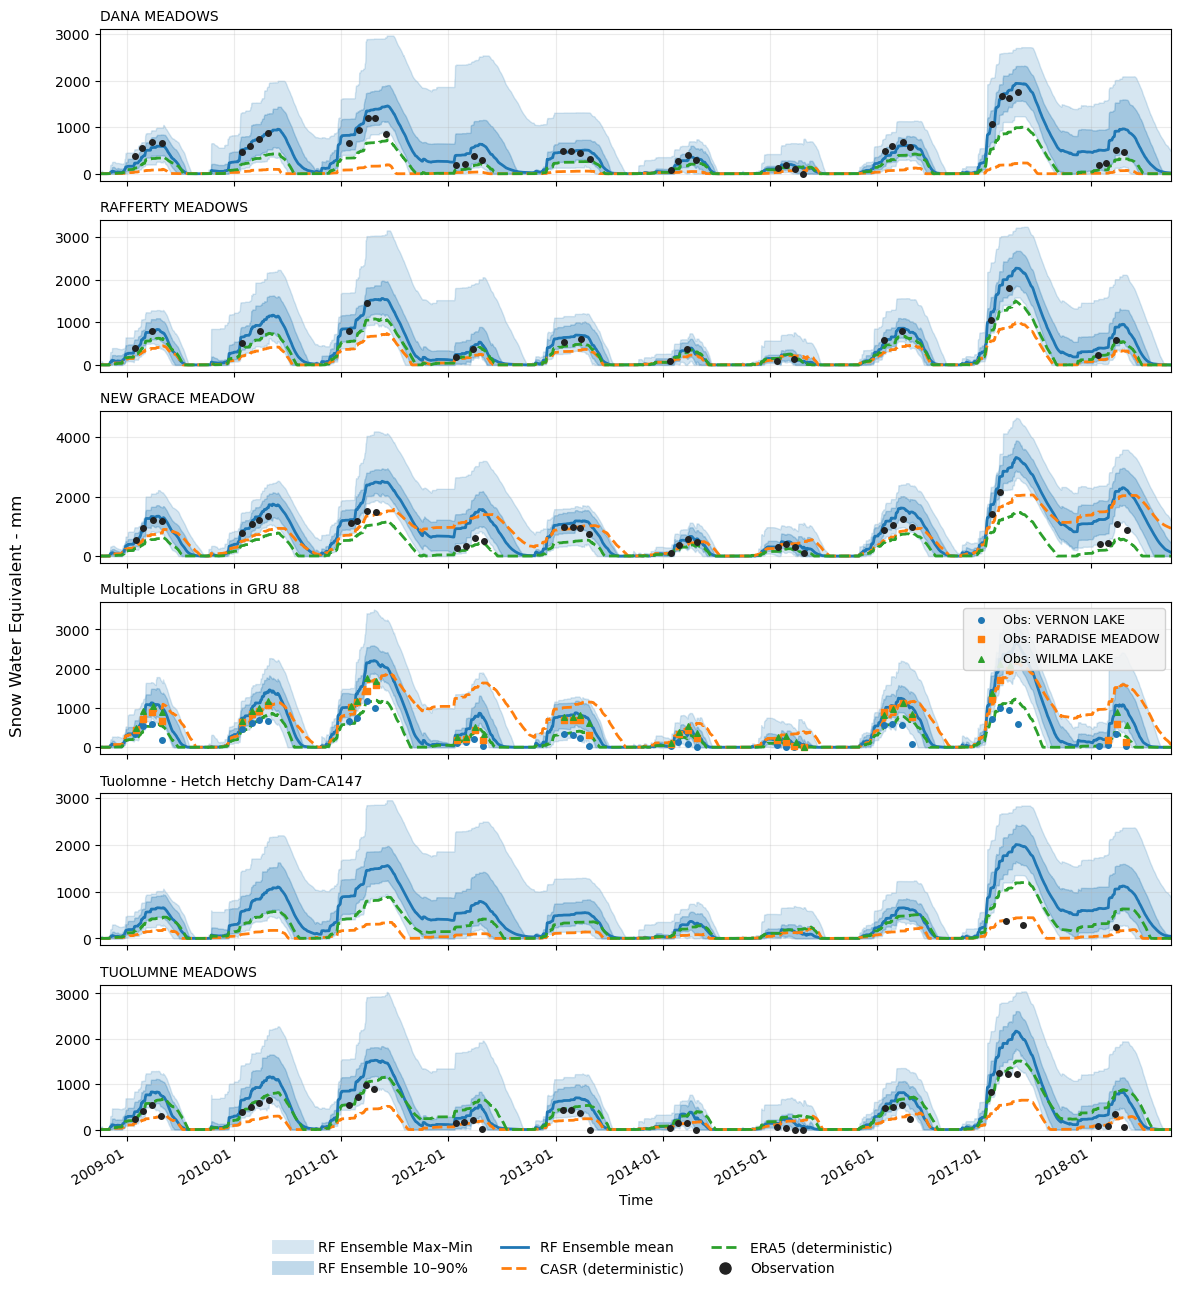

In [11]:
# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import logging

import numpy as np
import pandas as pd
import xarray as xr
from dask import compute
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colormaps  # Updated API

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)
logger = logging.getLogger(__name__)

# =========================
# Station helpers
# =========================
def select_top_stations_by_obs(
    ds: xr.Dataset,
    var: str = "snw",
    k: int = 8,
    time_range: Optional[Tuple[str, str]] = None,
) -> List[str]:
    da = ds[var]
    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))
    if "time" not in da.dims or "station_id" not in da.dims:
        raise ValueError("Expected dimensions 'time' and 'station_id' in station dataset.")
    counts = da.notnull().sum(dim="time").compute().values
    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    order = np.argsort(-counts)
    top = station_ids[order][:k]
    return list(top)

def read_station_data_for_gru(
    ds: xr.Dataset,
    gru_id: int,
    station_id_to_gru: pd.DataFrame,
    station_filter_ids: Optional[List[str]] = None,
    var: str = "snw",
    time_range: Optional[Tuple[str, str]] = None,
) -> Dict[str, xr.DataArray]:
    sid_map = station_id_to_gru.copy()
    sid_map["station_id"] = sid_map["station_id"].astype(str)
    matching_ids = sid_map.loc[sid_map["GRU_ID"] == gru_id, "station_id"].astype(str).tolist()
    if station_filter_ids is not None:
        filter_set = {str(s) for s in station_filter_ids}
        matching_ids = [s for s in matching_ids if s in filter_set]
    if not matching_ids:
        return {}
    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    station_names = np.asarray(ds["station_name"].load().values).astype(str)
    id_to_idx = {sid: i for i, sid in enumerate(station_ids)}
    chosen_indices = [id_to_idx[sid] for sid in matching_ids if sid in id_to_idx]
    if not chosen_indices:
        return {}
    da = ds[var].isel(station_id=chosen_indices).load()
    names = [station_names[i] for i in chosen_indices]
    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))
    return {names[j]: da.isel(station_id=j) for j in range(len(chosen_indices))}

# =========================
# NetCDF HRU/GRU selection
# =========================
def _choose_by_id_or_single(da: xr.DataArray, dim: str, target_id, id_coord_candidates):
    target_str = str(target_id)
    target_int = None
    try:
        target_int = int(target_id)
    except Exception:
        pass

    for cname in id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            vals = np.asarray(da.coords[cname].values)
            where = np.where(vals.astype(str) == target_str)[0]
            if where.size:
                return da.isel({dim: int(where[0])})
            if target_int is not None and np.issubdtype(vals.dtype, np.number):
                where = np.where(vals == target_int)[0]
                if where.size:
                    return da.isel({dim: int(where[0])})

    if da.sizes.get(dim, 0) == 1:
        return da.isel({dim: 0})

    if dim in da.coords:
        vals = np.asarray(da.coords[dim].values)
        if (vals.astype(str) == target_str).any():
            return da.sel({dim: target_str})
        if target_int is not None and np.issubdtype(vals.dtype, np.number) and (vals == target_int).any():
            return da.sel({dim: target_int})

    preview = {}
    for cname in [dim] + id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            preview[cname] = np.asarray(da.coords[cname].values)[:10].tolist()
    raise KeyError(
        f"Could not find {dim} with ID={target_id}. "
        f"Checked coords {list(preview.keys())}. First 10 values: {preview}"
    )

def open_member(nc_path: str, variable_name: str, hru_id, gru_id=None) -> Optional[xr.DataArray]:
    try:
        ds = xr.open_dataset(nc_path)
    except Exception as e:
        logger.error(f"Failed to open NetCDF file '{nc_path}': {e}", exc_info=True)
        return None
    if variable_name not in ds:
        return None
    da = ds[variable_name]
    if "hru" in da.dims:
        da = _choose_by_id_or_single(
            da, "hru", hru_id,
            id_coord_candidates=["hruId", "hru_id", "HRU_ID", "HRUId", "hruid"]
        )
        return da
    if "gru" in da.dims:
        if gru_id is None and "gruId" in ds.coords:
            vals = np.asarray(ds["gruId"].values)
            gru_id = int(vals[0]) if vals.size == 1 else None

        da = _choose_by_id_or_single(
            da, "gru", gru_id if gru_id is not None else 0,
            id_coord_candidates=["gruId", "gru_id", "GRU_ID", "GRUId", "gruid"]
        )
        return da
    return da

def load_ensemble(
    files: List[str], variable_name: str, hru_id: int, gru_id: Optional[int] = None
) -> Optional[xr.DataArray]:
    members = []
    for f in files:
        try:
            da = open_member(f, variable_name, hru_id, gru_id=gru_id)
        except RuntimeError as re:
            logger.error(f"RuntimeError caught while loading '{f}' for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
            continue
        except Exception as e:
            logger.error(f"General error caught while loading '{f}': {e}", exc_info=True)
            continue
        if da is not None:
            members.append(da)
    if not members:
        logger.warning(f"No valid ensemble members were loaded for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}, files={files}")
        return None
    try:
        ensemble = xr.concat(
            members,
            dim="member",
            join="outer",
            compat="override",
            coords="minimal",
        ).chunk({"member": -1})
    except Exception as e:
        logger.error(f"Error concatenating ensemble members for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {e}", exc_info=True)
        return None
    return ensemble

# =========================
# Plotting
# =========================

def build_color_map(ensemble_specs: List[dict]) -> Dict[str, str]:
    cmap = colormaps.get_cmap("tab10")
    labels = [spec["label"] for spec in ensemble_specs]
    unique_labels = list(dict.fromkeys(labels))
    return {lab: cmap(i % 10) for i, lab in enumerate(unique_labels)}

# New helper: A consistent color for observations (e.g., black)
def get_consistent_obs_color():
    return "#222222"

def build_station_obs_color_map(station_names: List[str], force_single_color: bool = False) -> Dict[str, str]:
    if force_single_color:
        color = get_consistent_obs_color()
        return {name: color for name in station_names}
    else:
        cmap = colormaps.get_cmap("tab10")
        return {name: cmap(i % 10) for i, name in enumerate(station_names)}

def compute_ensemble_summary(ensemble: xr.DataArray) -> Tuple[np.ndarray, ...]:
    mean_da = ensemble.mean(dim="member")
    p10_da = ensemble.quantile(0.1, dim="member")
    p90_da = ensemble.quantile(0.9, dim="member")
    vmin_da = ensemble.min(dim="member")
    vmax_da = ensemble.max(dim="member")
    mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)
    time = ensemble["time"].values
    return time, mean, p10, p90, vmin, vmax

def resolve_specs_for_gru(
    ensemble_specs: List[dict],
    variable_name: str,
    hru_id: int,
    gru_id: int,
    time_range: Optional[Tuple[str, str]],
) -> List[dict]:
    resolved = []
    for spec in ensemble_specs:
        label, files = spec["label"], spec["files"]
        is_det = bool(spec.get("deterministic", False))
        if is_det:
            nc = files[0]
            try:
                da = open_member(nc, variable_name, hru_id, gru_id=gru_id)
            except RuntimeError as re:
                logger.error(f"RuntimeError caught in resolve_specs_for_gru for deterministic '{nc}', variable='{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
                continue
            except Exception as e:
                logger.error(f"General error caught in resolve_specs_for_gru for deterministic '{nc}': {e}", exc_info=True)
                continue
            if da is None:
                continue
            if time_range:
                da = da.sel(time=slice(*time_range))
            resolved.append({"label": label, "kind": "det", "time": da["time"].values, "values": da.values})
        else:
            try:
                ens = load_ensemble(files, variable_name, hru_id, gru_id=gru_id)
            except RuntimeError as re:
                logger.error(f"RuntimeError caught in resolve_specs_for_gru for ensemble files={files}, variable='{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
                continue
            except Exception as e:
                logger.error(f"General error caught in resolve_specs_for_gru for ensemble files={files}: {e}", exc_info=True)
                continue
            if ens is None:
                continue
            if time_range:
                ens = ens.sel(time=slice(*time_range))
            t, mean, p10, p90, vmin, vmax = compute_ensemble_summary(ens)
            resolved.append({"label": label, "kind": "ens", "time": t, "mean": mean, "p10": p10, "p90": p90, "vmin": vmin, "vmax": vmax})
    return resolved

def plot_all_grus_one_figure(
    *,
    all_items: List[dict],
    variable_name: str,
    output_path: Path,
    time_range: Optional[Tuple[str, str]] = None,
    show: bool = False,
) -> None:
    """
    Plot ALL GRUs and their selected stations into ONE figure.
    all_items: list of dicts, each:
        {
          "gru_id": int,
          "hru_id": int,
          "station_data_dict": {station_name: xr.DataArray},
          "ensemble_specs": List[dict]  # files already filtered for this GRU
        }
    """
    # Count total subplots (one per GRU)
    total_rows = sum(1 for item in all_items if item["station_data_dict"])
    if total_rows == 0:
        logger.warning("No items to plot: total_rows is 0.")
        return

    # Build a unified color map across all ensemble labels present
    all_specs_flat = []
    for item in all_items:
        all_specs_flat.extend(item["ensemble_specs"])
    label_to_color = build_color_map(all_specs_flat)

    # Pre-resolve specs once per GRU
    for item in all_items:
        try:
            item["resolved_specs"] = resolve_specs_for_gru(
                item["ensemble_specs"],
                variable_name,
                item["hru_id"],
                item["gru_id"],
                time_range,
            )
        except Exception as e:
            logger.error(f"Error resolving specs for GRU {item.get('gru_id', '?')} (hru_id={item.get('hru_id', '?')}): {e}", exc_info=True)
            item["resolved_specs"] = []

    # Sort all_items by GRU ID
    all_items.sort(key=lambda x: x["gru_id"])

    # Prepare figure
    fig_h = max(2.2 * total_rows, 5.0)
    fig, axes = plt.subplots(nrows=total_rows, ncols=1, figsize=(12, fig_h), sharex=True, squeeze=False)
    axes = axes.ravel()

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h']

    # ----------- Prepare legend elements for all non-observation items -----
    global_legend_handles, global_legend_labels = [], []
    legend_keys_set = set()
    # Because repeated ensembles (with the same label) could appear across GRUs, use only first instance

    for item in all_items:
        resolved_specs = item.get("resolved_specs", [])
        for spec in resolved_specs:
            label = spec["label"]
            color = label_to_color.get(label, None)
            if color is None:
                continue
            # Use tuple as key for uniqueness
            if spec["kind"] == "det":
                key = (label, "det")
                label_str = f"{label} (deterministic)"
                if key not in legend_keys_set:
                    dummy_line, = plt.plot([], [], linestyle="--", linewidth=2, color=color, label=label_str)
                    global_legend_handles.append(dummy_line)
                    global_legend_labels.append(label_str)
                    legend_keys_set.add(key)
            else:
                # Max–Min
                key_mm = (label, "maxmin")
                label_mm = f"{label} Max–Min"
                if key_mm not in legend_keys_set:
                    dummy_fill_mm = plt.Line2D([], [], linestyle='-', color=color, alpha=0.18, linewidth=10, label=label_mm)
                    global_legend_handles.append(dummy_fill_mm)
                    global_legend_labels.append(label_mm)
                    legend_keys_set.add(key_mm)
                # 10–90%
                key_1090 = (label, "1090")
                label_1090 = f"{label} 10–90%"
                if key_1090 not in legend_keys_set:
                    dummy_fill_1090 = plt.Line2D([], [], linestyle='-', color=color, alpha=0.28, linewidth=10, label=label_1090)
                    global_legend_handles.append(dummy_fill_1090)
                    global_legend_labels.append(label_1090)
                    legend_keys_set.add(key_1090)
                # Mean
                key_mean = (label, "mean")
                label_mean = f"{label} mean"
                if key_mean not in legend_keys_set:
                    dummy_line_mean, = plt.plot([], [], color=color, linewidth=2, label=label_mean)
                    global_legend_handles.append(dummy_line_mean)
                    global_legend_labels.append(label_mean)
                    legend_keys_set.add(key_mean)

    # Add "Observation" legend entry at bottom, with consistent color
    obs_legend_color = get_consistent_obs_color()
    obs_legend_marker = 'o'
    obs_legend_handle = plt.Line2D([], [], linestyle='None', marker=obs_legend_marker, color=obs_legend_color, markersize=8, label='Observation')
    global_legend_handles.append(obs_legend_handle)
    global_legend_labels.append("Observation")

    # ----------- Plot per GRU -----------
    ax_idx = 0
    for item in all_items:
        station_data_dict = item["station_data_dict"]
        resolved_specs = item["resolved_specs"]
        if not station_data_dict or not resolved_specs:
            continue

        ax = axes[ax_idx]
        obs_handles, obs_labels = [], []

        # Plot ensembles (no legend for ensemble items in subplots)
        for spec in resolved_specs:
            label, color = spec["label"], label_to_color[spec["label"]]
            try:
                if spec["kind"] == "det":
                    ax.plot(spec["time"], spec["values"], linestyle="--", linewidth=2, color=color)
                else:
                    ax.fill_between(spec["time"], spec["vmin"], spec["vmax"], color=color, alpha=0.18)
                    ax.fill_between(spec["time"], spec["p10"], spec["p90"], color=color, alpha=0.28)
                    ax.plot(spec["time"], spec["mean"], color=color, linewidth=2)
            except Exception as e:
                logger.error(f"Error plotting ensemble/deterministic item for GRU {item.get('gru_id', '?')} (label={spec.get('label','?')}): {e}", exc_info=True)
                continue

        # Observations handling
        station_names = list(station_data_dict.keys())
        num_stations = len(station_names)
        if num_stations == 1:
            # Use consistent color for all obs (the one legend at bottom applies)
            station_color_map = build_station_obs_color_map(station_names, force_single_color=True)
        else:
            station_color_map = build_station_obs_color_map(station_names, force_single_color=False)

        for i, (station_name, obs_da) in enumerate(station_data_dict.items()):
            try:
                obs = obs_da.sel(time=slice(*time_range)) if time_range else obs_da
                marker = markers[i % len(markers)]
                scatter = ax.scatter(obs["time"].values, obs.values, s=16, color=station_color_map[station_name],
                                     marker=marker, zorder=3,
                                     label=f"Obs: {station_name}")
                obs_handles.append(scatter)
                obs_labels.append(f"Obs: {station_name}")
            except Exception as e:
                logger.error(f"Error plotting observations for station '{station_name}': {e}", exc_info=True)
                continue

        # Formatting
        ax.grid(True, alpha=0.25)

        # Subplot title
        if num_stations > 1:
            ax.set_title(f"Multiple Locations in GRU {item['gru_id']}", loc="left", fontsize=10)
        elif num_stations == 1:
            # Show the single station name as the title (no GRU shown)
            ax.set_title(station_names[0], loc="left", fontsize=10)
        else:
            # Just in case
            ax.set_title(f"GRU {item['gru_id']}", loc="left", fontsize=10)

        # Place obs legend in subplot (upper right) if observations present, only if more than one station
        if obs_handles and num_stations > 1:
            # Set legend with faint background for subplot obs legend
            legend = ax.legend(obs_handles, obs_labels, loc="upper right", fontsize=9, frameon=True, ncol=1)
            if legend:
                legend.get_frame().set_facecolor('#f3f3f3')
                legend.get_frame().set_alpha(0.88)

        ax_idx += 1

    # Shared labels & date formatting
    axes[-1].set_xlabel("Time")
    # --- Set y axis to custom legend instead of variable_name
    fig.supylabel("Snow Water Equivalent - mm")

    if time_range:
        start, end = time_range
        start_num = mdates.datestr2num(start)
        end_num = mdates.datestr2num(end)
        for ax in axes:
            ax.set_xlim(start_num, end_num)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    fig.autofmt_xdate()

    # Plot global (ensemble + obs) legend at bottom outside all axes, spanning full fig
    if global_legend_handles:
        fig.legend(global_legend_handles, global_legend_labels, loc='lower center', fontsize=10, frameon=False, ncol=3, bbox_to_anchor=(0.5, -0.01))

    fig.tight_layout(rect=[0.02, 0.04, 1, 0.97])
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    try:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
    except Exception as e:
        logger.error(f"Error saving figure to {output_path}: {e}", exc_info=True)
    if show:
        try:
            plt.show()
        except Exception as e:
            logger.error(f"Error displaying plot: {e}", exc_info=True)
    plt.close(fig)

# =========================
# Build ensemble specs for a GRU
# =========================
def build_ensemble_specs_for_gru(ensemble_sources: List[dict], gru_id: int) -> List[dict]:
    specs = []
    for src in ensemble_sources:
        src_dir = src["dir"]
        if not os.path.isdir(src_dir):
            continue
        files = [
            os.path.join(src_dir, f)
            for f in os.listdir(src_dir)
            if f.endswith(".nc") and any(f"G{int(gru_id):{pad}d}" in f for pad in ["02", "03", "04"])
        ]
        if not files:
            continue
        # For deterministics we keep first file by convention
        if src.get("deterministic", False) and len(files) > 1:
            files = [sorted(files)[0]]
        specs.append(
            {
                "label": src["label"],
                "files": files,
                "deterministic": bool(src.get("deterministic", False)),
            }
        )
    return specs

# =========================
# Example usage (adjust paths/vars as needed)
# =========================
if __name__ == "__main__":
    catchment = "tuolumne"
    num_stations = 25
    figure_directory = Path(f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/swe_figures_rf_compare/")
    figure_directory.mkdir(parents=True, exist_ok=True)
    variable_name = "scalarSWE"
    swe_observations_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/snow_data/{catchment}_NorSWE.nc"
    hru_csv_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/stations_with_hru_ids.csv"
    start_date = "2008-10-01"
    end_date = "2018-10-01"

    # Ensemble sources
    ensemble_sources = [
        {
            "label": "RF Ensemble",
            "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/",
            "color": "C1",
            "deterministic": False,
        },
        #{
        #    "label": "LWR Static",
        #    "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/",
        #    "color": "C2",
        #    "deterministic": False,
        #},
        {
            "label": "CASR",
            "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output",
            "color": "C3",
            "deterministic": True,
        },
        {
            "label": "ERA5",
            "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/era5_remapped/summa_output",
            "color": "C4",
            "deterministic": True,
        },
    ]

    try:
        SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
    except Exception as e:
        logger.error(f"Failed to open SWE observations NetCDF file at {swe_observations_path}: {e}", exc_info=True)
        raise

    try:
        SWE_stations_ds = filter_stations_by_obs_per_year(
            SWE_stations_ds_complete, var="snw", n=0,
            start_date=start_date, end_date=end_date,
            measurement_types=None
        )
    except Exception as e:
        logger.error(f"Failed to filter stations by obs per year: {e}", exc_info=True)
        raise

    try:
        hru_ids = pd.read_csv(hru_csv_path)
        hru_ids["station_id"] = hru_ids["station_id"].astype(str)
    except Exception as e:
        logger.error(f"Failed to read HRU CSV at {hru_csv_path}: {e}", exc_info=True)
        raise

    try:
        station_ids_in_ds = np.asarray(SWE_stations_ds["station_id"].load().values).astype(str)
        station_id_to_gru = hru_ids[hru_ids["station_id"].isin(station_ids_in_ds)]
        unique_gru_ids = station_id_to_gru["GRU_ID"].unique()
        top_station_ids = select_top_stations_by_obs(SWE_stations_ds, var="snw", k=num_stations, time_range=None)
    except Exception as e:
        logger.error(f"Error preparing GRU/station lists for plotting: {e}", exc_info=True)
        raise

    #Exclude specific GRUs (used for Banff diagrams)
    EXCLUDE_GRUS = set([int('152')])
    unique_gru_ids = [gru_id for gru_id in unique_gru_ids if gru_id not in EXCLUDE_GRUS]

    all_items = []
    for gru_id in unique_gru_ids:
        try:
            station_data = read_station_data_for_gru(
                SWE_stations_ds,
                gru_id=gru_id,
                station_id_to_gru=station_id_to_gru,
                station_filter_ids=top_station_ids,
                var="snw",
                time_range=("2008-08-01", "2018-10-31"),
            )
            if not station_data:
                continue
            specs = build_ensemble_specs_for_gru(ensemble_sources, gru_id)
            if not specs:
                continue
            hru_match = hru_ids.loc[hru_ids["GRU_ID"] == gru_id, "HRU_ID"].values
            if hru_match.size == 0:
                continue
            hru_id = int(hru_match[0])
            all_items.append(
                {
                    "gru_id": int(gru_id),
                    "hru_id": hru_id,
                    "station_data_dict": station_data,
                    "ensemble_specs": specs,
                }
            )
        except Exception as e:
            logger.error(f"Error assembling plot items for GRU {gru_id}: {e}", exc_info=True)
            continue

    out = figure_directory / f"compare_ALL_GRUs_{catchment}_{variable_name}.png"
    try:
        plot_all_grus_one_figure(
            all_items=all_items,
            variable_name=variable_name,
            output_path=out,
            time_range=(start_date, end_date),
            show=True,
        )
    except RuntimeError as re:
        logger.error(f"RuntimeError during plot_all_grus_one_figure: {re}", exc_info=True)
        print(f"RuntimeError encountered while plotting all GRUs: {re}")
    except Exception as e:
        logger.error(f"General error during plot_all_grus_one_figure: {e}", exc_info=True)
        print(f"General error encountered while plotting all GRUs: {e}")

2025-11-14 16:49:21,194 INFO Processing catchment: chena


2025-11-14 16:49:21,644 INFO Processing catchment: bow
2025-11-14 16:49:22,800 INFO Processing catchment: tuolumne


Saved figure to /anvil/projects/x-ees240082/users/dcasson/gpep/_combined/ensemble_generation/swe_figures_rf_compare/compare_ALL_GRUs_ALLCATCH_scalarSWE.png


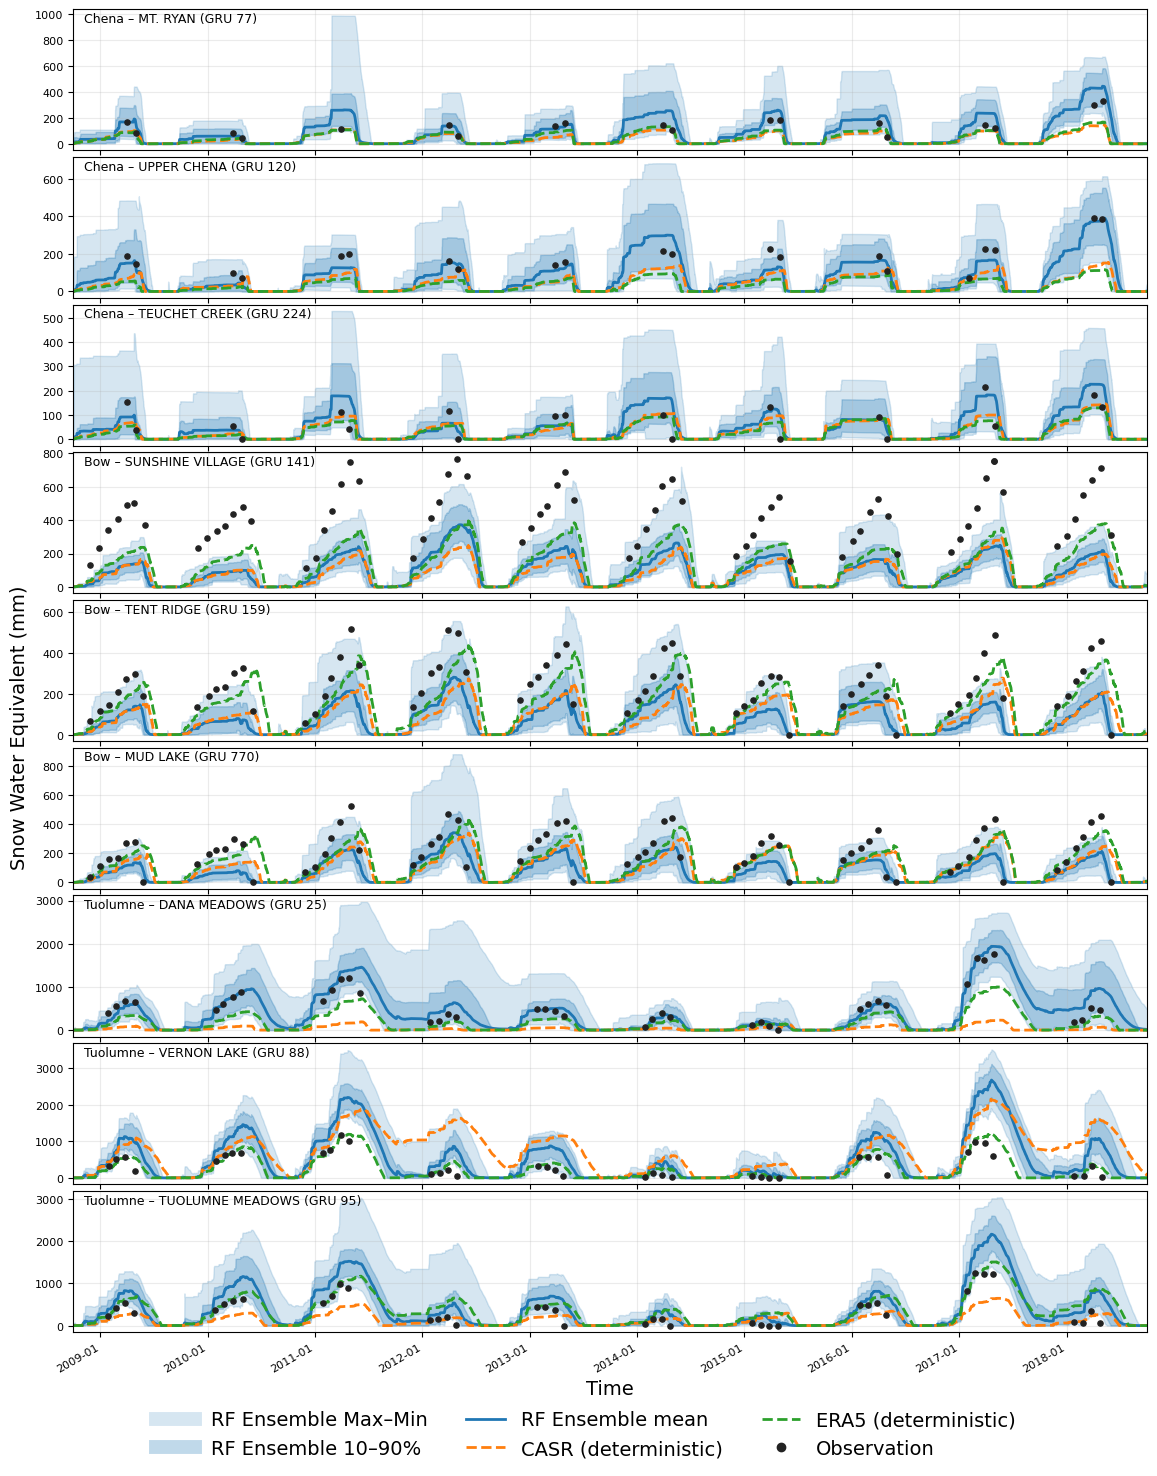

In [5]:
# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import logging

import numpy as np
import pandas as pd
import xarray as xr
from dask import compute
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colormaps
from matplotlib.lines import Line2D

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s"
)
logger = logging.getLogger(__name__)

# =========================
# Station helpers
# =========================
def select_top_stations_by_obs(
    ds: xr.Dataset,
    var: str = "snw",
    k: int = 8,
    time_range: Optional[Tuple[str, str]] = None,
) -> List[str]:
    da = ds[var]
    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))
    if "time" not in da.dims or "station_id" not in da.dims:
        raise ValueError("Expected dimensions 'time' and 'station_id' in station dataset.")
    counts = da.notnull().sum(dim="time").compute().values
    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    order = np.argsort(-counts)
    top = station_ids[order][:k]
    return list(top)

def read_station_data_for_gru(
    ds: xr.Dataset,
    gru_id: int,
    station_id_to_gru: pd.DataFrame,
    station_filter_ids: Optional[List[str]] = None,
    var: str = "snw",
    time_range: Optional[Tuple[str, str]] = None,
) -> Dict[str, xr.DataArray]:
    sid_map = station_id_to_gru.copy()
    sid_map["station_id"] = sid_map["station_id"].astype(str)
    matching_ids = sid_map.loc[sid_map["GRU_ID"] == gru_id, "station_id"].astype(str).tolist()
    if station_filter_ids is not None:
        filter_set = {str(s) for s in station_filter_ids}
        matching_ids = [s for s in matching_ids if s in filter_set]
    if not matching_ids:
        return {}
    station_ids = np.asarray(ds["station_id"].load().values).astype(str)
    station_names = np.asarray(ds["station_name"].load().values).astype(str)
    id_to_idx = {sid: i for i, sid in enumerate(station_ids)}
    chosen_indices = [id_to_idx[sid] for sid in matching_ids if sid in id_to_idx]
    if not chosen_indices:
        return {}
    da = ds[var].isel(station_id=chosen_indices).load()
    names = [station_names[i] for i in chosen_indices]
    if time_range:
        start, end = time_range
        da = da.sel(time=slice(start, end))
    return {names[j]: da.isel(station_id=j) for j in range(len(chosen_indices))}

# =========================
# NetCDF HRU/GRU selection
# =========================
def _choose_by_id_or_single(da: xr.DataArray, dim: str, target_id, id_coord_candidates):
    target_str = str(target_id)
    target_int = None
    try:
        target_int = int(target_id)
    except Exception:
        pass

    for cname in id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            vals = np.asarray(da.coords[cname].values)
            where = np.where(vals.astype(str) == target_str)[0]
            if where.size:
                return da.isel({dim: int(where[0])})
            if target_int is not None and np.issubdtype(vals.dtype, np.number):
                where = np.where(vals == target_int)[0]
                if where.size:
                    return da.isel({dim: int(where[0])})

    if da.sizes.get(dim, 0) == 1:
        return da.isel({dim: 0})

    if dim in da.coords:
        vals = np.asarray(da.coords[dim].values)
        if (vals.astype(str) == target_str).any():
            return da.sel({dim: target_str})
        if target_int is not None and np.issubdtype(vals.dtype, np.number) and (vals == target_int).any():
            return da.sel({dim: target_int})

    preview = {}
    for cname in [dim] + id_coord_candidates:
        if cname in da.coords and (dim in da.coords[cname].dims):
            preview[cname] = np.asarray(da.coords[cname].values)[:10].tolist()
    raise KeyError(
        f"Could not find {dim} with ID={target_id}. "
        f"Checked coords {list(preview.keys())}. First 10 values: {preview}"
    )

def open_member(nc_path: str, variable_name: str, hru_id, gru_id=None) -> Optional[xr.DataArray]:
    try:
        ds = xr.open_dataset(nc_path)
    except Exception as e:
        logger.error(f"Failed to open NetCDF file '{nc_path}': {e}", exc_info=True)
        return None
    if variable_name not in ds:
        return None
    da = ds[variable_name]
    if "hru" in da.dims:
        da = _choose_by_id_or_single(
            da, "hru", hru_id,
            id_coord_candidates=["hruId", "hru_id", "HRU_ID", "HRUId", "hruid"]
        )
        return da
    if "gru" in da.dims:
        if gru_id is None and "gruId" in ds.coords:
            vals = np.asarray(ds["gruId"].values)
            gru_id = int(vals[0]) if vals.size == 1 else None

        da = _choose_by_id_or_single(
            da, "gru", gru_id if gru_id is not None else 0,
            id_coord_candidates=["gruId", "gru_id", "GRU_ID", "GRUId", "gruid"]
        )
        return da
    return da

def load_ensemble(
    files: List[str], variable_name: str, hru_id: int, gru_id: Optional[int] = None
) -> Optional[xr.DataArray]:
    members = []
    for f in files:
        try:
            da = open_member(f, variable_name, hru_id, gru_id=gru_id)
        except RuntimeError as re:
            logger.error(f"RuntimeError caught while loading '{f}' for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
            continue
        except Exception as e:
            logger.error(f"General error caught while loading '{f}': {e}", exc_info=True)
            continue
        if da is not None:
            members.append(da)
    if not members:
        logger.warning(f"No valid ensemble members were loaded for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}, files={files}")
        return None
    try:
        ensemble = xr.concat(
            members,
            dim="member",
            join="outer",
            compat="override",
            coords="minimal",
        ).chunk({"member": -1})
    except Exception as e:
        logger.error(f"Error concatenating ensemble members for variable '{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {e}", exc_info=True)
        return None
    return ensemble

# =========================
# Plotting
# =========================

def build_color_map(ensemble_specs: List[dict]) -> Dict[str, str]:
    cmap = colormaps.get_cmap("tab10")
    labels = [spec["label"] for spec in ensemble_specs]
    unique_labels = list(dict.fromkeys(labels))
    return {lab: cmap(i % 10) for i, lab in enumerate(unique_labels)}

def get_consistent_obs_color():
    return "#222222"

def build_station_obs_color_map(station_names: List[str], force_single_color: bool = False) -> Dict[str, str]:
    if force_single_color:
        color = get_consistent_obs_color()
        return {name: color for name in station_names}
    else:
        cmap = colormaps.get_cmap("tab10")
        return {name: cmap(i % 10) for i, name in enumerate(station_names)}

def compute_ensemble_summary(ensemble: xr.DataArray) -> Tuple[np.ndarray, ...]:
    """
    Compute summary curves over the ensemble 'member' dimension:
    mean, 10th/90th percentiles, min, max. Returns (time, mean, p10, p90, vmin, vmax).
    """
    mean_da = ensemble.mean(dim="member")
    p10_da  = ensemble.quantile(0.1, dim="member")
    p90_da  = ensemble.quantile(0.9, dim="member")
    vmin_da = ensemble.min(dim="member")
    vmax_da = ensemble.max(dim="member")

    # dask.compute returns results in the same order as given:
    mean, p10, p90, vmin, vmax = compute(mean_da, p10_da, p90_da, vmin_da, vmax_da)

    time = ensemble["time"].values
    return time, mean, p10, p90, vmin, vmax

def resolve_specs_for_gru(
    ensemble_specs: List[dict],
    variable_name: str,
    hru_id: int,
    gru_id: int,
    time_range: Optional[Tuple[str, str]],
) -> List[dict]:
    resolved = []
    for spec in ensemble_specs:
        label, files = spec["label"], spec["files"]
        is_det = bool(spec.get("deterministic", False))
        if is_det:
            nc = files[0]
            try:
                da = open_member(nc, variable_name, hru_id, gru_id=gru_id)
            except RuntimeError as re:
                logger.error(f"RuntimeError in resolve_specs_for_gru deterministic '{nc}', var='{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
                continue
            except Exception as e:
                logger.error(f"General error in resolve_specs_for_gru deterministic '{nc}': {e}", exc_info=True)
                continue
            if da is None:
                continue
            if time_range:
                da = da.sel(time=slice(*time_range))
            resolved.append({"label": label, "kind": "det", "time": da["time"].values, "values": da.values})
        else:
            try:
                ens = load_ensemble(files, variable_name, hru_id, gru_id=gru_id)
            except RuntimeError as re:
                logger.error(f"RuntimeError in resolve_specs_for_gru ensemble files={files}, var='{variable_name}', hru_id={hru_id}, gru_id={gru_id}: {re}", exc_info=True)
                continue
            except Exception as e:
                logger.error(f"General error in resolve_specs_for_gru ensemble files={files}: {e}", exc_info=True)
                continue
            if ens is None:
                continue
            if time_range:
                ens = ens.sel(time=slice(*time_range))
            t, mean, p10, p90, vmin, vmax = compute_ensemble_summary(ens)
            resolved.append({"label": label, "kind": "ens", "time": t, "mean": mean, "p10": p10, "p90": p90, "vmin": vmin, "vmax": vmax})
    return resolved

def _add_catchment_separators(fig: plt.Figure, axes, plotted_items: List[dict]) -> None:
    """
    Add visual separators and headers per catchment across stacked subplots.
    - Catchment name appears once per group, above the first axis in that group
    - Draws a thin horizontal line between catchment blocks
    - Does NOT change axes background colors
    """
    # Normalize axes to a Python list
    if isinstance(axes, np.ndarray):
        axes_list = list(axes.ravel())
    elif isinstance(axes, (list, tuple)):
        axes_list = list(axes)
    else:
        axes_list = [axes] if axes is not None else []

    if len(axes_list) == 0 or not plotted_items:
        return

    # Only group over catchments found in plotted_items, using their first encountered order
    groups = []
    current_name = None
    start = 0
    for idx, item in enumerate(plotted_items):
        name = item.get("catchment_name", "unknown")
        if current_name is None:
            current_name = name
            start = idx
        elif name != current_name:
            groups.append((current_name, start, idx - 1))
            current_name = name
            start = idx
    groups.append((current_name, start, len(plotted_items) - 1))

    for gi, (name, start_idx, end_idx) in enumerate(groups):
        # Header label above the first axis in this group; capitalize only
        ax0 = axes_list[start_idx]
        ax0.text(
            0.0, 1.03, f"{name.capitalize()}",
            transform=ax0.transAxes, fontsize=11,
            ha="left", va="bottom"
        )

        # Separator line above this group (except first)
        if gi > 0:
            y = axes_list[start_idx].get_position().y1 + 0.01
            line = Line2D(
                [0.02, 0.98], [y, y],
                transform=fig.transFigure,
                linewidth=0.8, color="#999999", alpha=0.7
            )
            fig.add_artist(line)

# Main plotting function (now supports per-item catchment labeling)
def plot_all_grus_one_figure(
    *,
    all_items: List[dict],
    variable_name: str,
    output_path: Path,
    time_range: Optional[Tuple[str, str]] = None,
    show: bool = False,
    catchment_name: Optional[str] = None,  # fallback if item doesn't carry one
) -> None:
    """
    Plot ALL GRUs (across multiple catchments) into ONE figure.
    all_items: list of dicts, each:
        {
          "gru_id": int,
          "hru_id": int,
          "station_data_dict": {station_name: xr.DataArray},
          "ensemble_specs": List[dict],
          "catchment_name": str   # used for labels/titles & separators
        }
    """
    # Pre-resolve specs once per item and filter out items with no data/specs
    for item in all_items:
        try:
            item["resolved_specs"] = resolve_specs_for_gru(
                item["ensemble_specs"],
                variable_name,
                item["hru_id"],
                item["gru_id"],
                time_range,
            )
        except Exception as e:
            logger.error(f"Error resolving specs for GRU {item.get('gru_id','?')} (hru_id={item.get('hru_id','?')}): {e}", exc_info=True)
            item["resolved_specs"] = []

    # Keep only items with data and specs
    filtered_items = [
        it for it in all_items
        if it.get("station_data_dict") and it.get("resolved_specs")
    ]
    if not filtered_items:
        logger.warning("No items to plot: no GRUs/stations with resolved specs.")
        return

    # Sort by catchment order, then GRU within catchment.
    # Hard code preferred catchment order (Chena, Bow, Tuolumne, then any others alphabetically)
    catchment_order = ["chena", "bow", "tuolumne"]
    def catchment_sort_key(it):
        name = it.get("catchment_name", "")
        # Always lowercase for matching order
        try:
            idx = catchment_order.index(name.lower())
        except ValueError:
            other_names = sorted(
                set(
                    x.get("catchment_name", "")
                    for x in filtered_items
                    if x.get("catchment_name", "").lower() not in catchment_order
                )
            )
            idx = len(catchment_order) + other_names.index(name)
        return (idx, int(it.get("gru_id", 0)))
    filtered_items.sort(key=catchment_sort_key)

    # Build unified color map across all ensemble labels (after filtering)
    all_specs_flat = []
    for item in filtered_items:
        all_specs_flat.extend(item["ensemble_specs"])
    label_to_color = build_color_map(all_specs_flat)

    # Count total subplots
    total_rows = len(filtered_items)

    # Prepare figure (slightly more compact vertically)
    fig_h = max(1.6 * total_rows + 1.2, 6.0)
    fig, axes = plt.subplots(
        nrows=total_rows, ncols=1,
        figsize=(12, fig_h),
        sharex=True, squeeze=False
    )
    axes = axes.ravel()

    # Slightly smaller but manuscript-friendly tick labels
    for ax in axes:
        ax.tick_params(labelsize=8)

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h']

    # ----------- Prepare legend elements for all non-observation items -----
    global_legend_handles, global_legend_labels = [], []
    legend_keys_set = set()
    for item in filtered_items:
        resolved_specs = item.get("resolved_specs", [])
        for spec in resolved_specs:
            label = spec["label"]
            color = label_to_color.get(label, None)
            if color is None:
                continue
            if spec["kind"] == "det":
                key = (label, "det")
                label_str = f"{label} (deterministic)"
                if key not in legend_keys_set:
                    dummy_line, = plt.plot([], [], linestyle="--", linewidth=2, color=color, label=label_str)
                    global_legend_handles.append(dummy_line)
                    global_legend_labels.append(label_str)
                    legend_keys_set.add(key)
            else:
                # Max–Min
                key_mm = (label, "maxmin")
                label_mm = f"{label} Max–Min"
                if key_mm not in legend_keys_set:
                    dummy_fill_mm = plt.Line2D([], [], linestyle='-', color=color, alpha=0.18, linewidth=10, label=label_mm)
                    global_legend_handles.append(dummy_fill_mm)
                    global_legend_labels.append(label_mm)
                    legend_keys_set.add(key_mm)
                # 10–90%
                key_1090 = (label, "1090")
                label_1090 = f"{label} 10–90%"
                if key_1090 not in legend_keys_set:
                    dummy_fill_1090 = plt.Line2D([], [], linestyle='-', color=color, alpha=0.28, linewidth=10, label=label_1090)
                    global_legend_handles.append(dummy_fill_1090)
                    global_legend_labels.append(label_1090)
                    legend_keys_set.add(key_1090)
                # Mean
                key_mean = (label, "mean")
                label_mean = f"{label} mean"
                if key_mean not in legend_keys_set:
                    dummy_line_mean, = plt.plot([], [], color=color, linewidth=2, label=label_mean)
                    global_legend_handles.append(dummy_line_mean)
                    global_legend_labels.append(label_mean)
                    legend_keys_set.add(key_mean)

    # Add "Observation" legend entry at bottom, with consistent color
    obs_legend_color = get_consistent_obs_color()
    obs_legend_marker = 'o'
    obs_legend_handle = plt.Line2D(
        [], [], linestyle='None',
        marker=obs_legend_marker,
        color=obs_legend_color, markersize=6,
        label='Observation'
    )
    global_legend_handles.append(obs_legend_handle)
    global_legend_labels.append("Observation")

    # ----------- Plot per item (GRU) -----------
    ax_idx = 0
    for item in filtered_items:
        station_data_dict = item["station_data_dict"]
        resolved_specs = item["resolved_specs"]

        ax = axes[ax_idx]
        obs_handles, obs_labels = [], []

        # Plot ensembles (no per-axes legend; a global legend below)
        for spec in resolved_specs:
            label, color = spec["label"], label_to_color[spec["label"]]
            try:
                if spec["kind"] == "det":
                    ax.plot(spec["time"], spec["values"], linestyle="--", linewidth=2, color=color)
                else:
                    ax.fill_between(spec["time"], spec["vmin"], spec["vmax"], color=color, alpha=0.18)
                    ax.fill_between(spec["time"], spec["p10"], spec["p90"], color=color, alpha=0.28)
                    ax.plot(spec["time"], spec["mean"], color=color, linewidth=2)
            except Exception as e:
                logger.error(f"Error plotting ensemble/deterministic item for GRU {item.get('gru_id', '?')} (label={spec.get('label','?')}): {e}", exc_info=True)
                continue

        # Observations (labels now are station names only; catchment appears once at group header)
        station_names = list(station_data_dict.keys())
        num_stations = len(station_names)
        if num_stations == 1:
            station_color_map = build_station_obs_color_map(station_names, force_single_color=True)
        else:
            station_color_map = build_station_obs_color_map(station_names, force_single_color=False)

        for i, (station_name, obs_da) in enumerate(station_data_dict.items()):
            try:
                obs = obs_da.sel(time=slice(*time_range)) if time_range else obs_da
                marker = markers[i % len(markers)]
                label_text = station_name
                scatter = ax.scatter(
                    obs["time"].values, obs.values,
                    s=14, color=station_color_map[station_name],
                    marker=marker, zorder=3, label=label_text
                )
                obs_handles.append(scatter)
                obs_labels.append(label_text)
            except Exception as e:
                logger.error(f"Error plotting observations for station '{station_name}': {e}", exc_info=True)
                continue

        # Formatting
        ax.grid(True, alpha=0.25)

        # Subplot title (move to top-left *inside* axes)
        catchment_for_title = item.get("catchment_name", None)
        catchment_str = f"{catchment_for_title.capitalize()} – " if catchment_for_title else ""

        title_str = ""
        if num_stations > 1:
            title_str = f"{catchment_str}GRU {item['gru_id']} • Multiple locations"
        elif num_stations == 1:
            title_str = f"{catchment_str}{station_names[0]} (GRU {item['gru_id']})"
        else:
            title_str = f"{catchment_str}GRU {item['gru_id']}"

        # Place title anchored at axes (left/top), reduce pad so subplots can be closer
        ax.text(0.01, 0.98, title_str, fontsize=9, ha="left", va="top", transform=ax.transAxes)

        # Per-subplot obs legend if multiple stations
        if obs_handles and num_stations > 1:
            legend = ax.legend(
                obs_handles, obs_labels,
                loc="upper right",
                fontsize=8,
                frameon=True,
                ncol=1
            )
            if legend:
                legend.get_frame().set_facecolor('white')
                legend.get_frame().set_alpha(1.0)

        ax_idx += 1

    # Shared labels & date formatting
    axes[-1].set_xlabel("Time", fontsize=14)
    fig = plt.gcf()
    # --- Reduce space between y-axis label and plots ---
    fig.supylabel("Snow Water Equivalent (mm)", fontsize=14)  # labelpad is not valid here

    if time_range:
        start, end = time_range
        start_num = mdates.datestr2num(start)
        end_num = mdates.datestr2num(end)
        for ax in axes:
            ax.set_xlim(start_num, end_num)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    else:
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    fig.autofmt_xdate()

    # Add catchment separators & headers (catchment names appear once per group)
    #_add_catchment_separators(fig, axes, filtered_items)

    # Global legend at bottom
    if global_legend_handles:
        fig.legend(
            global_legend_handles, global_legend_labels,
            loc='lower center',
            fontsize=14,
            frameon=False,
            ncol=3,
            bbox_to_anchor=(0.5, 0.02)
        )

    # Make plots closer together vertically by reducing hspace
    fig.tight_layout(rect=[0, 0.06, 0.98, 0.97], h_pad=0.1)
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    try:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"Saved figure to {output_path}")
    except Exception as e:
        logger.error(f"Error saving figure to {output_path}: {e}", exc_info=True)
    if show:
        try:
            plt.show()
        except Exception as e:
            logger.error(f"Error displaying plot: {e}", exc_info=True)
    plt.close(fig)

# =========================
# Build ensemble specs for a GRU
# =========================
import re

def build_ensemble_specs_for_gru(ensemble_sources: List[dict], gru_id: int) -> List[dict]:
    """
    Find files whose filename contains a GRU id matching `gru_id`, regardless of zero-padding or
    token style (e.g., G45, G045, G0045, GRU0045). We parse numeric chunks following 'G' or 'GRU'
    and compare as integers.
    """
    target = int(gru_id)
    specs = []

    # Regex: 'G' or 'GRU' followed by 1+ digits, e.g., G45, GRU0045
    pat = re.compile(r'(?:^|[^A-Za-z0-9])(GRU|G)(\d+)(?:[^0-9]|$)')

    def file_matches(path: str) -> bool:
        fn = os.path.basename(path)
        for m in pat.finditer(fn):
            try:
                val = int(m.group(2))
                if val == target:
                    return True
            except Exception:
                pass
        # As a fallback, also allow plain zero-padded substrings like _G0045_ or -0045.nc if present
        # without an explicit 'G' token (rare, but safe to include):
        zpads = {f"{target}", f"{target:02d}", f"{target:03d}", f"{target:04d}", f"{target:05d}"}
        return any(z in fn for z in (f"G{z}" for z in zpads)) or any(z in fn for z in (f"GRU{z}" for z in zpads))

    for src in ensemble_sources:
        src_dir = src["dir"]
        if not os.path.isdir(src_dir):
            continue

        nc_files = [os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.endswith(".nc")]
        files = [p for p in nc_files if file_matches(p)]

        if not files:
            continue

        # For deterministics, keep first file by convention
        if src.get("deterministic", False) and len(files) > 1:
            files = [sorted(files)[0]]

        specs.append(
            {
                "label": src["label"],
                "files": files,
                "deterministic": bool(src.get("deterministic", False)),
            }
        )

    return specs

# =========================
# Combined-run entry point
# =========================
if __name__ == "__main__":
    # Catchments and per-catchment top-N, in preferred order/capitalization
    catchments = ["chena", "bow", "tuolumne"]  # lower for folder structure, but capitalized for plot
    top_n_per_catchment = {
        "chena": 3,
        "bow": 11,
        "tuolumne": 3,
    }

    variable_name = "scalarSWE"
    start_date = "2008-10-01"
    end_date = "2018-10-01"
    obs_time_range = ("2008-08-01", "2018-10-31")

    combined_items: List[dict] = []

    for catchment in catchments:
        logger.info(f"Processing catchment: {catchment}")

        swe_observations_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/snow_data/{catchment}_NorSWE.nc"
        hru_csv_path = f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/stations_with_hru_ids.csv"

        # Ensemble sources (catchment-specific roots already parameterized)
        ensemble_sources = [
            {
                "label": "RF Ensemble",
                "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/",
                "deterministic": False,
            },
            # {
            #     "label": "LWR Static",
            #     "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/lwr_best_regression_static/summa/output/",
            #     "deterministic": False,
            # },
            {
                "label": "CASR",
                "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/casr_remapped/summa_output",
                "deterministic": True,
            },
            {
                "label": "ERA5",
                "dir": f"/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/ensemble_generation/era5_remapped/summa_output",
                "deterministic": True,
            },
        ]

        # --- Load observations dataset
        try:
            SWE_stations_ds_complete = xr.open_dataset(swe_observations_path)
        except Exception as e:
            logger.error(f"[{catchment}] Failed to open SWE observations NetCDF: {swe_observations_path}: {e}", exc_info=True)
            continue

        # Optional: filter stations (as you had)
        try:
            SWE_stations_ds = filter_stations_by_obs_per_year(
                SWE_stations_ds_complete, var="snw", n=0,
                start_date=start_date, end_date=end_date,
                measurement_types=[0]
            )
        except Exception as e:
            logger.error(f"[{catchment}] Failed to filter stations by obs per year: {e}", exc_info=True)
            continue

        # Read HRU/GRU mapping
        try:
            hru_ids = pd.read_csv(hru_csv_path)
            hru_ids["station_id"] = hru_ids["station_id"].astype(str)
        except Exception as e:
            logger.error(f"[{catchment}] Failed to read HRU CSV at {hru_csv_path}: {e}", exc_info=True)
            continue

        # Pick top-N stations for this catchment
        try:
            station_ids_in_ds = np.asarray(SWE_stations_ds["station_id"].load().values).astype(str)
            station_id_to_gru = hru_ids[hru_ids["station_id"].isin(station_ids_in_ds)]
            unique_gru_ids = station_id_to_gru["GRU_ID"].unique()
            k = int(top_n_per_catchment.get(catchment, 8))  # default fallback
            top_station_ids = select_top_stations_by_obs(SWE_stations_ds, var="snw", k=k, time_range=None)
        except Exception as e:
            logger.error(f"[{catchment}] Error preparing GRU/station lists for plotting: {e}", exc_info=True)
            continue

        # (Optional) Exclusions
        EXCLUDE_GRUS = set([int('152')])
        unique_gru_ids = [gru_id for gru_id in unique_gru_ids if gru_id not in EXCLUDE_GRUS]

        # Assemble combined items
        for gru_id in unique_gru_ids:
            try:
                station_data = read_station_data_for_gru(
                    SWE_stations_ds,
                    gru_id=gru_id,
                    station_id_to_gru=station_id_to_gru,
                    station_filter_ids=top_station_ids,
                    var="snw",
                    time_range=obs_time_range,
                )
                if not station_data:
                    continue
                specs = build_ensemble_specs_for_gru(ensemble_sources, gru_id)
                if not specs:
                    continue
                hru_match = hru_ids.loc[hru_ids["GRU_ID"] == gru_id, "HRU_ID"].values
                if hru_match.size == 0:
                    continue
                hru_id = int(hru_match[0])
                combined_items.append(
                    {
                        "gru_id": int(gru_id),
                        "hru_id": hru_id,
                        "station_data_dict": station_data,
                        "ensemble_specs": specs,
                        "catchment_name": catchment,  # will be capitalized in plotting
                    }
                )
            except Exception as e:
                logger.error(f"[{catchment}] Error assembling plot items for GRU {gru_id}: {e}", exc_info=True)
                continue

    # Save ONE combined figure
    if not combined_items:
        logger.warning("No GRUs with station+ensemble data found across all catchments.")
    else:
        out_dir = Path(f"/anvil/projects/x-ees240082/users/dcasson/gpep/_combined/ensemble_generation/swe_figures_rf_compare/")
        out_dir.mkdir(parents=True, exist_ok=True)
        out = out_dir / f"compare_ALL_GRUs_ALLCATCH_{variable_name}.png"

        try:
            plot_all_grus_one_figure(
                all_items=combined_items,
                variable_name=variable_name,
                output_path=out,
                time_range=(start_date, end_date),
                show=True,
                catchment_name=None,  # per-item names will be used and capitalized
            )
        except RuntimeError as re:
            logger.error(f"RuntimeError during combined plot_all_grus_one_figure: {re}", exc_info=True)
            print(f"RuntimeError encountered while plotting combined figure: {re}")
        except Exception as e:
            logger.error(f"General error during combined plot_all_grus_one_figure: {e}", exc_info=True)
            print(f"General error encountered while plotting combined figure: {e}")